# 14. Data quality and descriptive trends

## tl;dr

The processing layers pass their structural integrity checks, but buyer identifiers, duration, amount, and independent reference validation remain material limitations. Quarterly PELT results are descriptive break signals, not causal explanations or forecasts.

## Context & Methods

The unit is one awarded Grand Ouest digital procurement episode. The trend window starts at 2015Q2 because the raw extract begins in March 2015. PELT uses standardized quarterly counts and a log(n) penalty with sensitivity multipliers 0.5, 1, and 2.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'scripts').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROCESSED = PROJECT_ROOT / 'data/processed/boamp'
with open(PROCESSED / 'data_quality_profile.json', encoding='utf-8') as f:
    quality = json.load(f)
with open(PROCESSED / 'trend_analysis_summary.json', encoding='utf-8') as f:
    trend_summary = json.load(f)
quarterly = pd.read_csv(PROCESSED / 'trend_quarterly.csv', parse_dates=['quarter_start'])
breakpoints = pd.read_csv(PROCESSED / 'trend_breakpoints.csv')
signals = pd.read_csv(PROCESSED / 'trend_signal_matrix.csv')


## Data

In [2]:
pd.DataFrame([
    {'metric': 'standardized notices', 'value': quality['volume']['standardized_notices']},
    {'metric': 'reconstructed episodes', 'value': quality['volume']['reconstructed_episodes']},
    {'metric': 'study cohort episodes', 'value': quality['volume']['survival_cohort_rows']},
    {'metric': 'candidate pairs', 'value': quality['volume']['candidate_pairs']},
    {'metric': 'primary successor events', 'value': quality['volume']['accepted_primary_links']},
])

,metric,value
0,standardized notices,1620712
1,reconstructed episodes,1103632
2,study cohort episodes,3800
3,candidate pairs,763417
4,primary successor events,544


In [3]:
pd.Series(quality['cohort_missingness'], name='missing_rate').sort_values(ascending=False).to_frame()

,missing_rate
reliable_duration,0.7492
buyer_siren,0.6634
amount_candidate_container,0.1568
main_cpv,0.0000
episode_text,0.0000
award_date,0.0000


## Results

,segment,state,quarters_used,slope_episodes_per_quarter,annualized_slope_episodes,recent_mean_episodes_per_quarter,annualized_slope_relative_to_recent_mean,p_value,r_squared,alpha,last_central_break,last_stable_break,central_break_count,stable_break_count,hmm_current_regime,hmm_current_regime_probability,business_recommendation
0,Overall,stable_or_uncertain,12,-0.108392,-0.433566,78.583333,-0.005517,0.921363,0.001024,0.1,2023Q2,NaN,1,0,growth,0.749876,Maintain monitoring for Overall; no statistica...
1,CPV-32,stable_or_uncertain,12,-0.006993,-0.027972,22.500000,-0.001243,0.988790,0.000021,0.1,2020Q2,2020Q2,1,1,growth,0.991616,Maintain monitoring for CPV-32; no statistical...
2,CPV-35,stable_or_uncertain,12,0.034965,0.139860,10.333333,0.013535,0.922687,0.000990,0.1,2020Q2,NaN,2,0,NaN,NaN,Maintain monitoring for CPV-35; no statistical...
3,CPV-48,decreasing,12,-0.835664,-3.342657,14.250000,-0.234572,0.031704,0.383715,0.1,2024Q1,2024Q1,1,1,NaN,NaN,Investigate the recent decline in CPV-48 befor...
4,CPV-72,stable_or_uncertain,12,0.699301,2.797203,31.500000,0.088800,0.285437,0.112973,0.1,2023Q1,2021Q1,2,1,growth,0.593927,Maintain monitoring for CPV-72; no statistical...


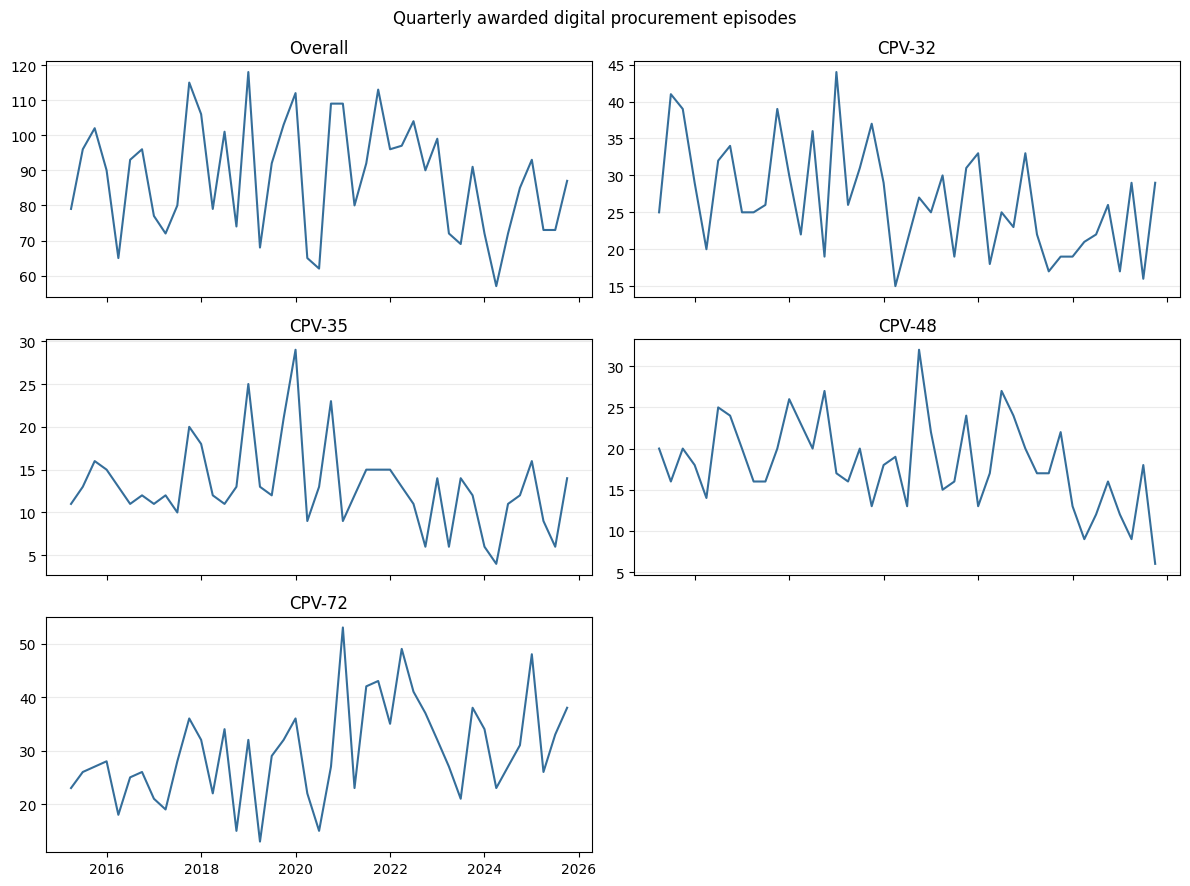

In [4]:
display(signals)
fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
for ax, (segment, group) in zip(axes.flatten(), quarterly.groupby('segment', sort=False)):
    group = group.sort_values('quarter_start')
    ax.plot(group['quarter_start'], group['episode_count'], color='#356E9A')
    ax.set_title(segment)
    ax.grid(axis='y', alpha=0.25)
axes.flatten()[-1].axis('off')
fig.suptitle('Quarterly awarded digital procurement episodes')
plt.tight_layout()

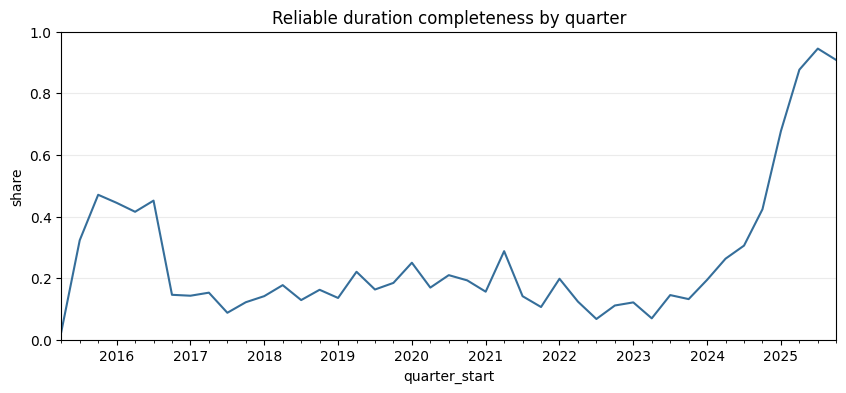

In [5]:
overall = quarterly.loc[quarterly['segment'].eq('Overall')].sort_values('quarter_start')
ax = overall.plot(x='quarter_start', y='duration_completeness', figsize=(10, 4), legend=False, color='#356E9A')
ax.set_title('Reliable duration completeness by quarter')
ax.set_ylabel('share')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.25)

## Takeaways

- The cohort has enough episodes for descriptive survival analysis, but the event definition remains linkage-conditioned.
- Duration missingness changes sharply over time, so global duration imputation would create unsupported temporal structure.
- PELT breaks are candidates for documentary interpretation, not causal findings.
- Reference metrics are regional reference-sample evidence; independent specialist review is still needed before any external accuracy claim.